In [41]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

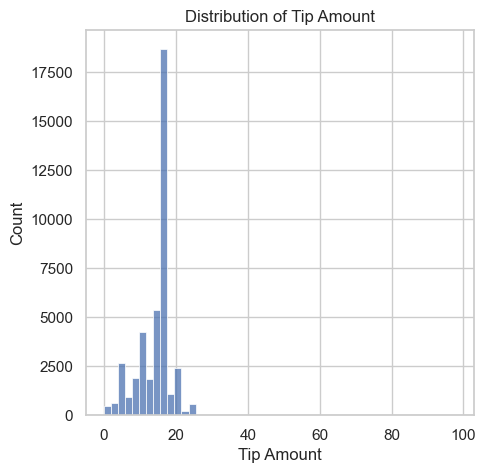

In [42]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print(taxi.shape), 
display(taxi.head())
taxi.info()
display(taxi.describe())
display(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
  # (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(5,5))
sns.histplot(taxi["tip_amount"], bins=50)
plt.title("Distribution of Tip Amount")
# plt.xlim(50, 100)
plt.xlabel("Tip Amount")
plt.ylabel("Count")
plt.show()


The data has 41202 rows, 13 columns. there are no null values in the dataset. There are only two data types present; integers and floating point numbers. Even though they are all numbers, the purpose of some integers are rather categorical than numerical values. The class label, tip amount is a float, which hints that this problem is a regression problem instead of a classification one.

The distribution of the tip amount is skewed to the right, with most values falling in the 16 - 17 dollar range. A small number of tips were at the higher ends of the tip amount, with the highest tipped amount being 98 dollars. The presence of such high value tips in relation to this distribution suggests that there are potential outliers within the distribution.
There were no absolute zeros, but the smallest amount that was tipped was 0.01 dollars, which is about a cent.

In [43]:
from sklearn.preprocessing import StandardScaler

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
clean_taxi = taxi.copy()

missing = taxi.isnull().sum()
clean_taxi = clean_taxi[clean_taxi["trip_distance"] > 0]
clean_taxi = clean_taxi[clean_taxi["fare_amount"] > 0]
clean_taxi = clean_taxi[clean_taxi["tip_amount"] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

clean_taxi["fare_per_mile"] = clean_taxi["fare_amount"] / clean_taxi["trip_distance"]
clean_taxi["total_surcharges"] = clean_taxi["mta_tax"] + clean_taxi["tolls_amount"] + clean_taxi["improvement_surcharge"]

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

categoricals = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type"
]

clean_taxi_encoded = pd.get_dummies(clean_taxi, columns=categoricals, drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
scaler = StandardScaler()

We ensured that the trip distance and fare amount is greater than zero, we also ensured that the tip amount was not a negative number.

We derived the feature fare per mile, which can be used a uniform metric to measure rate of the fare per unit distance.

We also derived the total surchages, which can be used as a total sum of payment a user has to pay, apart from the actual fare amount.

We used the standard scaling because it is not sensitive to outliers.

In [44]:
from sklearn.model_selection import train_test_split

# TODO: Separate features (X) and target (y = tip_amount)
X = clean_taxi_encoded.drop(columns = "tip_amount")
y = clean_taxi_encoded["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)
#   (Explain in the reasoning box why scaling must be fit on train only.)

I used a ration of 60/40/40. A separate validation set is required for picking the best hypothesis function and tuning hyperparameters. The scaler and other imputation statistics must be fit on only the training data only because of data leakage. The model should not be exposed to computaions that require the input of the validation and testing data.

Linear Regression
Training: 4.7764 0.0624
Validation:   5.0465 0.0451
Testing:  5.0169 0.0496

Random Forest
Training: 2.8414 0.6682
Validation:   5.6513 -0.1975
Testing:  5.6216 -0.1932


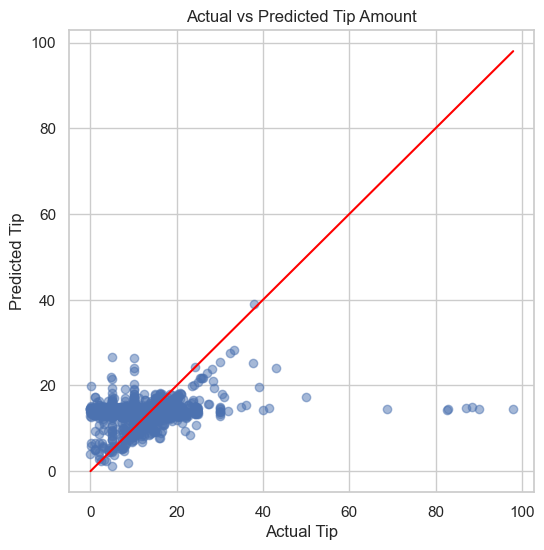

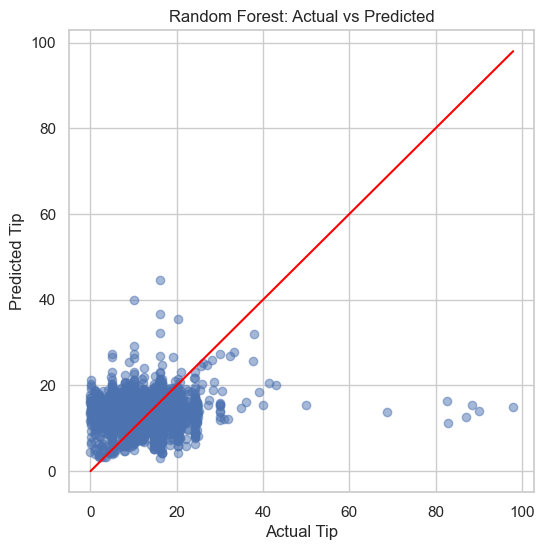

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train_scaled, y_train)


# TODO: Predict on train, validation, and test sets.
lin_train_pred = lin_model.predict(X_train_scaled)
lin_val_pred   = lin_model.predict(X_val_scaled)
lin_test_pred  = lin_model.predict(X_test_scaled)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_val_pred   = rf_model.predict(X_val_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# lin_train_rmse = mean_squared_error(y_train, lin_train_pred) ** 0.5
# lin_train_r2 = r2_score(y_train, lin_train_pred)

# lin_val_rmse = mean_squared_error(y_val, lin_val_pred) ** 0.5
# lin_val_r2 = r2_score(y_val, lin_val_pred)

# lin_test_rmse = mean_squared_error(y_test, lin_test_pred) ** 0.5
# lin_test_r2 = r2_score(y_test, lin_test_pred)


# rf_train_rmse = mean_squared_error(y_train, rf_train_pred) ** 0.5
# rf_train_r2 = r2_score(y_train, rf_train_pred)

# rf_val_rmse = mean_squared_error(y_val, rf_val_pred) ** 0.5
# rf_val_r2 = r2_score(y_val, rf_val_pred)

# rf_test_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5
# rf_test_r2 = r2_score(y_test, rf_test_pred)


def evaluate(y_true, y_pred):
  rmse = mean_squared_error(y_true, y_pred) ** 0.5
  r2 = r2_score(y_true, y_pred)
  return rmse, r2

lin_train_rmse, lin_train_r2 = evaluate(y_train, lin_train_pred)
lin_val_rmse, lin_val_r2 = evaluate(y_val, lin_val_pred)
lin_test_rmse, lin_test_r2 = evaluate(y_test, lin_test_pred)

rf_train_rmse, rf_train_r2 = evaluate(y_train, rf_train_pred)
rf_val_rmse, rf_val_r2 = evaluate(y_val, rf_val_pred)
rf_test_rmse, rf_test_r2 = evaluate(y_test, rf_test_pred)

print("Linear Regression")
print("Training:", round(lin_train_rmse, 4), round(lin_train_r2, 4))
print("Validation:  ", round(lin_val_rmse, 4), round(lin_val_r2, 4))
print("Testing: ", round(lin_test_rmse, 4), round(lin_test_r2, 4))

print("\nRandom Forest")
print("Training:", round(rf_train_rmse, 4), round(rf_train_r2, 4))
print("Validation:  ", round(rf_val_rmse, 4), round(rf_val_r2, 4))
print("Testing: ", round(rf_test_rmse, 4), round(rf_test_r2, 4))

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

plt.figure(figsize=(6,6))
plt.scatter(y_test, lin_test_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip Amount")
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.show()


The linear regression model performed slightly better on the validation set.  
  
For the hyper parameters I tried an n_estimators value of 100.  
  
For Linear Regression, Even though the results were consistent, it was underfitting. For $R^2$, we obtainted 0.0624, 0.0451 and 0.0496 for training, validation, and testing respectively.  

For Random Forest Regression, The model was overfitting. For the training data, It had a promising R^2 of 0.6682. It drastically dropped for the validation data, with a value of -0.1975. The testing data also had the same trend, with an R^2 value of -0.1932.  
  
To reduce the fitting for the above model, we can limit the tree depth, or increase the min samples per leaf.  

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

NObeyesdad
Obesity_Type_I         0.166272
Obesity_Type_III       0.153482
Obesity_Type_II        0.140692
Overweight_Level_I     0.137376
Overweight_Level_II    0.137376
Normal_Weight          0.135955
Insufficient_Weight    0.128849
Name: proportion, dtype: float64


<Axes: xlabel='count', ylabel='NObeyesdad'>

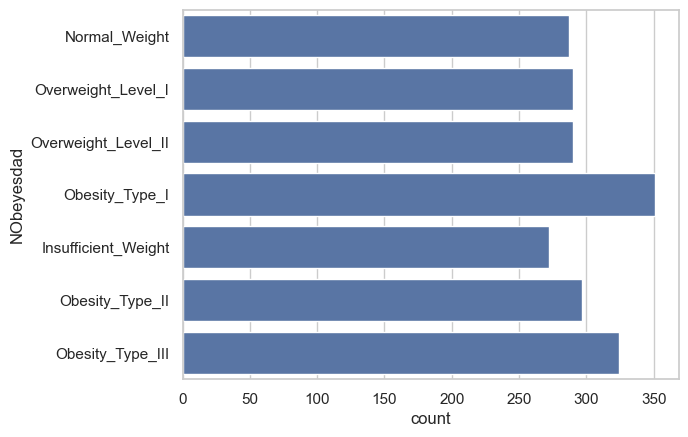

In [46]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape), 
display(obesity.head())
obesity.info()
display(obesity.describe())
display(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print(obesity['NObeyesdad'].value_counts(normalize=True))
sns.countplot(y=obesity['NObeyesdad'])

There are 21,111 features in the dataset.

The target is fairly balance accross the 7 classes, even though it would be better to have less of the "Obesity Type 1".

Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE are numeric.  
  
FAVC, CALC,MTRANS,NObeyesdad,SCC,SMOKE,CAEC,and family_history_with_overweight are categorical.  
  
Class balance or imbalance matters because the frequency of a particular class has an influence on the hypothetical function or the model. Thus if you have more of a class, there is a high likelyhood that your model will predict that class a lot more.

In [47]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder


# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
decision = {"yes": 1, "no": 0}

obesity["FAVC"] = obesity["FAVC"].map(decision)
obesity["SMOKE"] = obesity["SMOKE"].map(decision)
obesity["SCC"] = obesity["SCC"].map(decision)
obesity["family_history_with_overweight"] = obesity["family_history_with_overweight"].map(decision)


ord_encoder = OrdinalEncoder(categories=[
    ["no", "Sometimes", "Frequently", "Always"]
])

obesity[["CAEC"]] = ord_encoder.fit_transform(obesity[["CAEC"]])
obesity[["CALC"]] = ord_encoder.fit_transform(obesity[["CALC"]])

obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
obesity["BMI"] = obesity["Weight"] / (obesity["Height"]**2)
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

print(obesity.head(10))

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3)
scaler = StandardScaler()

    Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  NCP  \
0  21.0    1.62    64.0                               1     0   2.0  3.0   
1  21.0    1.52    56.0                               1     0   3.0  3.0   
2  23.0    1.80    77.0                               1     0   2.0  3.0   
3  27.0    1.80    87.0                               0     0   3.0  3.0   
4  22.0    1.78    89.8                               0     0   2.0  1.0   
5  29.0    1.62    53.0                               0     1   2.0  3.0   
6  23.0    1.50    55.0                               1     1   3.0  3.0   
7  22.0    1.64    53.0                               0     0   2.0  3.0   
8  24.0    1.78    64.0                               1     1   3.0  3.0   
9  22.0    1.72    68.0                               1     1   2.0  3.0   

   CAEC  SMOKE  CH2O  SCC  FAF  TUE  CALC  NObeyesdad  Gender_Male  \
0   1.0      0   2.0    0  0.0  1.0   0.0           1        False   
1   1.0      1   3.0   

In [48]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

X = obesity.drop(columns = "NObeyesdad")
#Same as X = obesity.drop("NObeyesdad", axis = 1)
y = obesity["NObeyesdad"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify = y_temp
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

I chose a split of 60/20/20 for training, validation and testing respectively.  
  
Stratify was used to make sure every dataset split still looks like the original dataset in terms of class balance.  
  
If not done, the balance of the classes will vary from training, validation and testing datasets. And therefore, the model will learn biased patterns

Training: 0.9241706161137441 0.9216924878748501
Validation:   0.8791469194312796 0.8728259358673748
Testing:  0.8936170212765957 0.8895425359817121
[[54  0  0  0  0  0  0]
 [ 5 42  0  0  0 10  1]
 [ 0  0 66  2  0  0  2]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  4  0  0  0 46  8]
 [ 0  1  4  0  0  7 46]]


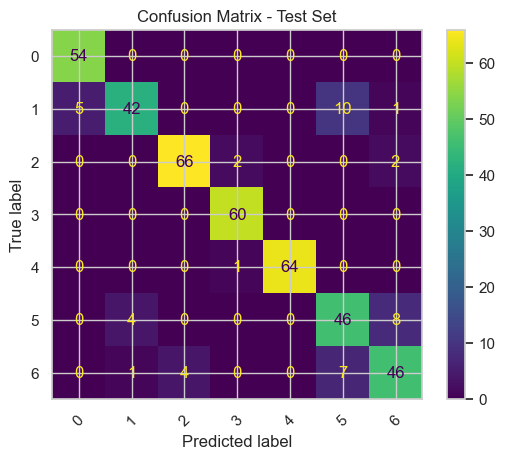

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_model.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
lr_train_pred = lr_model.predict(X_train_scaled)
lr_val_pred   = lr_model.predict(X_val_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_cls(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    return acc, f1

train_acc, train_f1 = evaluate_cls(y_train, lr_train_pred)
val_acc, val_f1     = evaluate_cls(y_val, lr_val_pred)
test_acc, test_f1   = evaluate_cls(y_test, lr_test_pred)

print("Training:", train_acc, train_f1)
print("Validation:  ", val_acc, val_f1)
print("Testing: ", test_acc, test_f1)

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

print(confusion_matrix(y_test, lr_test_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_test_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Test Set")
plt.show()

I chose Logistical Regression because it is easier to interpret, faster, and lightweight.  
  
The model is well fitted, even though it is very slightly overfitted. The model achieved accuracy levels of 0.924, 0.879 and 0.894 for training, validation and testing respectively.

From the confusion matrix, we see that the obesity levels that are hardest to tell apart are those which are adjacent to each other. This might be because in reality, obesity is a spectrum, and not bound by defined sets of categories.

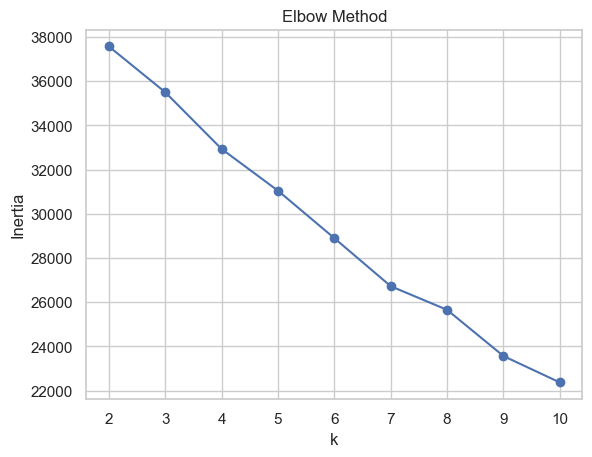

[(2, 0.1786575330957639), (3, 0.1874826891152316), (4, 0.15317402694366433), (5, 0.11065828738381485), (6, 0.12046009029774278), (7, 0.13866406830129194), (8, 0.1549433665528676), (9, 0.16873274982507197), (10, 0.1702210299125823)]


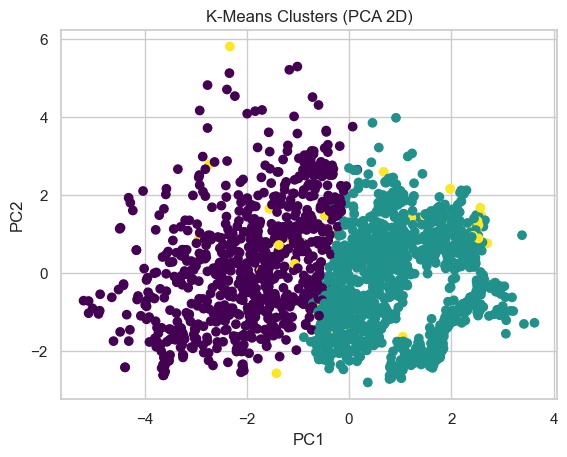

NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,265,257,18,1,0,130,80
1,6,17,327,281,323,157,205
2,1,13,6,15,1,3,5


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# TODO: Use ONLY the scaled obesity features (no target) for clustering.
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(X)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
print(list(zip(k_range, sil_scores)))


# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_cluster)

plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_labels, cmap='viridis')
plt.title("K-Means Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

pd.crosstab(cluster_labels, obesity['NObeyesdad'])

1. I chose K by looking at the highest silhouette score. k = 3 had the highest silhouette score of 0.1874.  
  
2. Looking at the crosstab, the unsupervised clusters do not fully represent the real obesity levels, but for the first 2 clusters, we are able to see a trend, with cluster 0 leaning towards the smaller obesity levels, whilst cluster 1 leans towards the higher obesity levels. Cluster 2 on the other hand is a smaller, weaker cluster.  
  
3. These clusters will be useful to be able to map health issues to the particular cluster based on weight, height, or eating habits. This way, it is easier for diagnosis and treatment.


**Reflection**
1. The classifier was able to eventually map out certain traits into certain predefined classes, Whilst K-Means was able to find hidden patterns amongnst datapoints and place them in groups or clusters.  

2. For evaluating tips, we used $r^2$ and RMSE, which took into consideration how close the numerical value was to the actual value. For obesity, evaluations were done based on whether a prediction was explicitly correct or wrong. macro-F1 was used.  
   
3. Across all the three fitting, the biggest train vs test gap was that of the taxi tip. The single most effective thing I would do is to do regularization.